# Mechanistic Interpretability — Visual Experiments

> **Goal:** Make the core mech-interp ideas concrete — features as directions, superposition, polysemantic neurons, and SAE feature recovery.

## What we'll explore

| # | Experiment | Question answered |
|---|---|---|
| 1 | **Features as directions** | Can a feature be read out by projecting onto its direction? |
| 2 | **Superposition** | Does a model pack more sparse features than it has dimensions? |
| 3 | **Polysemantic neurons** | Why can't we read a single neuron as one concept? |
| 4 | **SAE recovery** | Does a sparse autoencoder recover features better than the neuron basis? |

---
**Linked theory:** [research/01-mechanistic-interpretability-overview.md](../research/01-mechanistic-interpretability-overview.md)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import warnings
warnings.filterwarnings('ignore')

torch.manual_seed(0)
np.random.seed(42)
plt.rcParams.update({
    'figure.dpi': 110,
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'axes.grid': True,
    'grid.alpha': 0.35,
})
print('Setup complete.')

Setup complete.


---
## Experiment 1: Features as directions

**Question:** Mech interp's first claim is that a feature corresponds to a *direction* in activation space. If activations are sums of feature directions, can we read a feature off by projecting?

We build activations as weighted sums of fixed feature directions and recover one feature's value by projecting onto its (dual) direction.

In [2]:
np.random.seed(1)

d, n = 6, 3
F = np.random.randn(d, n); F /= np.linalg.norm(F, axis=0)   # 3 feature directions in 6-D
vals = np.random.rand(2000, n)                              # feature activations
acts = vals @ F.T                                           # activations (2000, d) = sum of feature directions

# read features by projecting onto the dual directions (pseudo-inverse), shape (d, n)
readout = np.linalg.pinv(F.T)                                # (d, n): acts @ readout -> (2000, n)
recovered = acts @ readout
r2 = 1 - ((vals[:, 0] - recovered[:, 0]) ** 2).sum() / ((vals[:, 0] - vals[:, 0].mean()) ** 2).sum()
print(f'feature-0 readout R^2 via direction projection: {r2:.3f}')

feature-0 readout R^2 via direction projection: 1.000


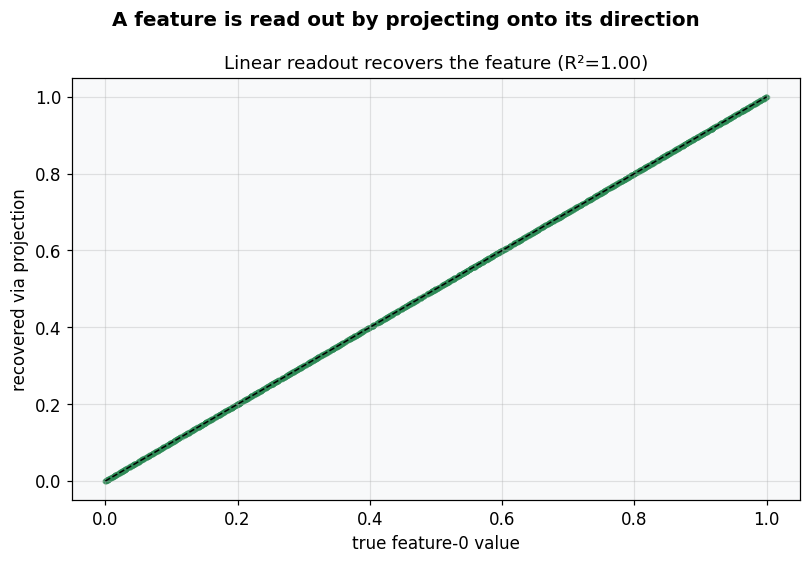

In [3]:
fig, ax = plt.subplots(figsize=(7.5, 5.2))
fig.suptitle('A feature is read out by projecting onto its direction', fontsize=13, fontweight='bold')

ax.scatter(vals[:, 0], recovered[:, 0], s=8, alpha=0.4, color='seagreen')
ax.plot([0, 1], [0, 1], 'k--', lw=1)
ax.set_xlabel('true feature-0 value'); ax.set_ylabel('recovered via projection')
ax.set_title(f'Linear readout recovers the feature (R²={r2:.2f})')

plt.tight_layout()
plt.show()

### What you see

1. **What the plot shows:** The recovered feature value tracks the true value almost exactly (points on the diagonal, R²≈1).
2. **Why it looks this way:** When activations are linear combinations of feature directions, projecting onto the right (dual) direction isolates one feature. This is exactly what a linear probe does.
3. **Key takeaway:** 'Features are directions' is what makes probing, TCAV, and steering vectors work — read or push a concept by its direction.

---
## Experiment 2: Superposition

**Question:** Can a model represent *more* features than it has dimensions? Anthropic's toy model says yes — when features are sparse.

We train the toy model (project $n$ sparse features into $d<n$ dims, reconstruct) at low and high sparsity and inspect which features get represented.

In [4]:
torch.manual_seed(2)
d, n = 5, 20                       # 5 dims must hold up to 20 features
importance = torch.tensor([0.85 ** i for i in range(n)], dtype=torch.float32)


def train_toy(p_active, steps=4000):
    W = nn.Parameter(torch.randn(d, n) * 0.1)
    b = nn.Parameter(torch.zeros(n))
    opt = torch.optim.Adam([W, b], lr=2e-3)
    for _ in range(steps):
        x = (torch.rand(1024, n) < p_active).float() * torch.rand(1024, n)   # sparse features
        h = x @ W.T
        xr = torch.relu(h @ W + b)
        loss = (importance * (x - xr) ** 2).mean()
        opt.zero_grad(); loss.backward(); opt.step()
    return W.detach().numpy()


W_dense = train_toy(0.9)    # features almost always on -> little superposition
W_sparse = train_toy(0.05)  # features rare -> superposition
norm_dense = np.linalg.norm(W_dense, axis=0)
norm_sparse = np.linalg.norm(W_sparse, axis=0)
print(f'features represented (||col|| > 0.3)  dense: {(norm_dense>0.3).sum()}/{n}   sparse: {(norm_sparse>0.3).sum()}/{n}')

features represented (||col|| > 0.3)  dense: 5/20   sparse: 13/20


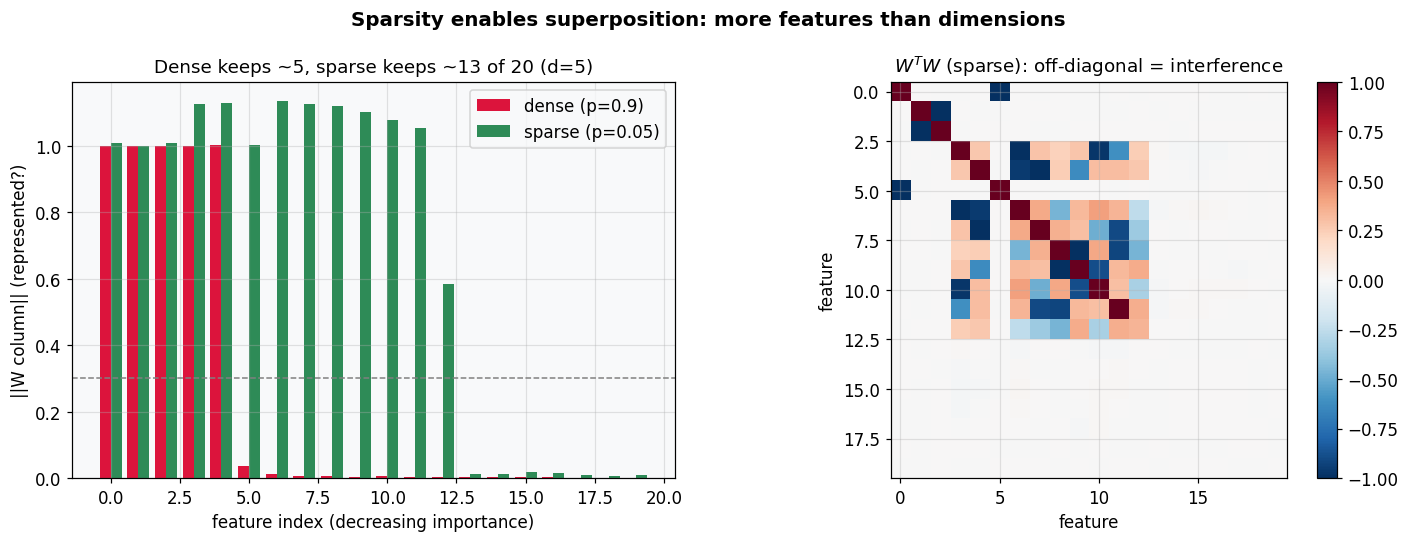

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Sparsity enables superposition: more features than dimensions', fontsize=13, fontweight='bold')

ax = axes[0]
ax.bar(np.arange(n) - 0.2, norm_dense, 0.4, color='crimson', label='dense (p=0.9)')
ax.bar(np.arange(n) + 0.2, norm_sparse, 0.4, color='seagreen', label='sparse (p=0.05)')
ax.axhline(0.3, color='gray', ls='--', lw=1)
ax.set_xlabel('feature index (decreasing importance)'); ax.set_ylabel('||W column|| (represented?)')
ax.set_title(f'Dense keeps ~{(norm_dense>0.3).sum()}, sparse keeps ~{(norm_sparse>0.3).sum()} of {n} (d={d})')
ax.legend()

G = W_sparse.T @ W_sparse
im = axes[1].imshow(G, cmap='RdBu_r', vmin=-1, vmax=1)
axes[1].set_title('$W^T W$ (sparse): off-diagonal = interference')
axes[1].set_xlabel('feature'); axes[1].set_ylabel('feature')
fig.colorbar(im, ax=axes[1], fraction=0.046)

plt.tight_layout()
plt.show()

### What you see

1. **What the plot shows:** With dense features (red) only about $d=5$ features get a non-zero column — the model can't fit more. With sparse features (green) many more than 5 are represented. The $W^TW$ heatmap shows non-zero off-diagonals: features share directions, interfering slightly.
2. **Why it looks this way:** When features rarely co-occur, the model can overlap them in the same dimensions and rarely pays the interference cost — so it crams $>d$ features into $d$ dims via superposition.
3. **Key takeaway:** Superposition is real and sparsity-driven: a model encodes far more concepts than it has neurons, which is why neurons aren't clean feature readouts.

---
## Experiment 3: Polysemantic neurons

**Question:** Superposition predicts that a single neuron (dimension) responds to several unrelated features. Does the trained model show this?

We look at how strongly each hidden dimension reads each feature (a row of $W$) — a polysemantic neuron has several large entries.

In [6]:
# each hidden neuron j reads features via row W_sparse[j, :]
neuron = int(np.argmax((np.abs(W_sparse) > 0.3).sum(1)))   # the most polysemantic neuron
weights = W_sparse[neuron]
strong = np.where(np.abs(weights) > 0.3)[0]
print(f'neuron {neuron} responds strongly to features: {strong.tolist()}')

neuron 4 responds strongly to features: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12]


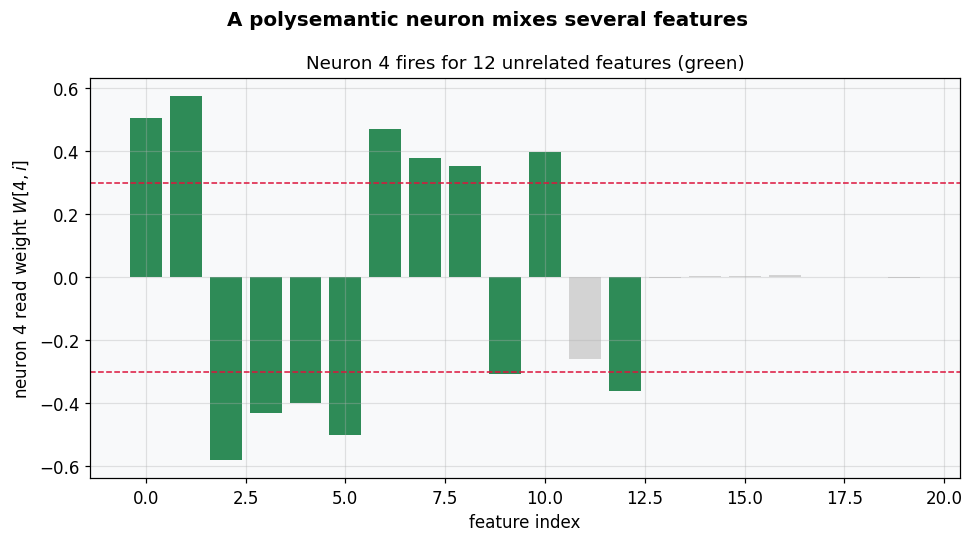

In [7]:
fig, ax = plt.subplots(figsize=(9, 5))
fig.suptitle('A polysemantic neuron mixes several features', fontsize=13, fontweight='bold')

colors = ['seagreen' if i in strong else 'lightgray' for i in range(n)]
ax.bar(range(n), weights, color=colors)
ax.axhline(0.3, color='crimson', ls='--', lw=1); ax.axhline(-0.3, color='crimson', ls='--', lw=1)
ax.set_xlabel('feature index'); ax.set_ylabel(f'neuron {neuron} read weight $W[{neuron}, i]$')
ax.set_title(f'Neuron {neuron} fires for {len(strong)} unrelated features (green)')

plt.tight_layout()
plt.show()

### What you see

1. **What the plot shows:** The chosen neuron has several entries above the threshold (green) — it responds substantially to multiple distinct features, not one.
2. **Why it looks this way:** Because features are superposed, each dimension carries a mix of them. Reading the neuron's activation alone cannot tell you which feature is active.
3. **Key takeaway:** Polysemanticity is why you can't interpret a network neuron-by-neuron — the meaningful units (features) are spread across neurons, motivating a change of basis.

---
## Experiment 4: SAE recovery

**Question:** A sparse autoencoder learns an overcomplete dictionary to undo superposition. Does it recover the true feature directions better than the raw neuron basis?

We generate superposed activations, train an SAE, and measure how well its dictionary atoms align with the true feature directions versus the standard neuron basis.

In [8]:
torch.manual_seed(4)
Wt = torch.tensor(W_sparse, dtype=torch.float32)     # true feature directions (d x n) in activation space


def gen_acts(batch):
    x = (torch.rand(batch, n) < 0.05).float() * torch.rand(batch, n)
    return x @ Wt.T


m = 40   # overcomplete dictionary size
enc = nn.Linear(d, m); dec = nn.Linear(m, d, bias=False)
opt = torch.optim.Adam(list(enc.parameters()) + list(dec.parameters()), lr=2e-3)
for _ in range(4000):
    h = gen_acts(1024)
    c = torch.relu(enc(h))
    hr = dec(c)
    loss = ((hr - h) ** 2).mean() + 1e-2 * c.abs().mean()   # reconstruction + L1 sparsity
    opt.zero_grad(); loss.backward(); opt.step()

D = dec.weight.detach().numpy()                 # d x m dictionary atoms (columns)
D = D / (np.linalg.norm(D, axis=0, keepdims=True) + 1e-8)
true_dirs = W_sparse / (np.linalg.norm(W_sparse, axis=0, keepdims=True) + 1e-8)
neuron_basis = np.eye(d)

represented = np.where(np.linalg.norm(W_sparse, axis=0) > 0.3)[0]
sae_align = [np.abs(true_dirs[:, i] @ D).max() for i in represented]
neuron_align = [np.abs(true_dirs[:, i] @ neuron_basis).max() for i in represented]
print(f'mean alignment to true features  SAE: {np.mean(sae_align):.3f}   neuron basis: {np.mean(neuron_align):.3f}')

mean alignment to true features  SAE: 0.930   neuron basis: 0.648


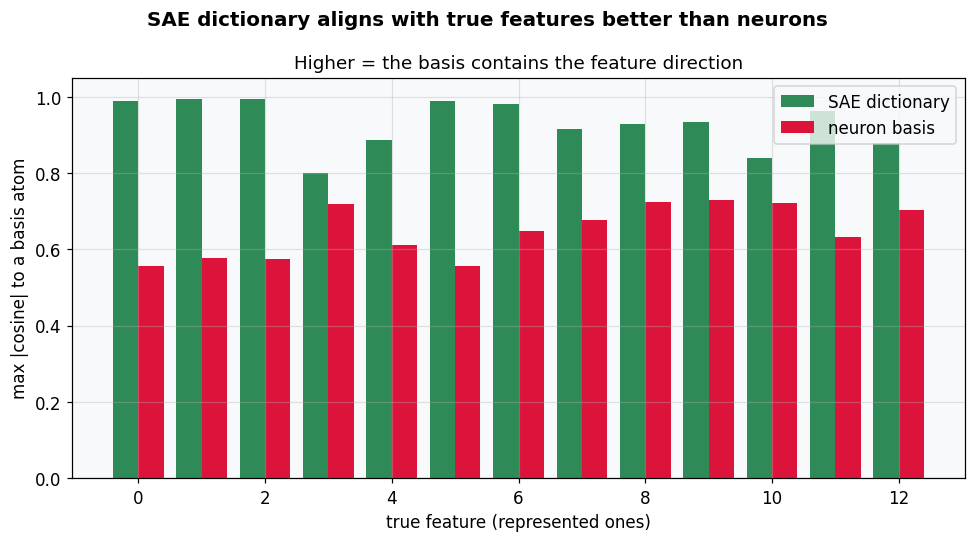

In [9]:
fig, ax = plt.subplots(figsize=(9, 5))
fig.suptitle('SAE dictionary aligns with true features better than neurons', fontsize=13, fontweight='bold')

x = np.arange(len(represented)); w = 0.4
ax.bar(x - w/2, sae_align, w, color='seagreen', label='SAE dictionary')
ax.bar(x + w/2, neuron_align, w, color='crimson', label='neuron basis')
ax.set_xlabel('true feature (represented ones)'); ax.set_ylabel('max |cosine| to a basis atom')
ax.set_title('Higher = the basis contains the feature direction')
ax.legend(); ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

### What you see

1. **What the plot shows:** For most represented features, the SAE dictionary (green) has an atom that aligns strongly (cosine near 1) with the true feature direction, while the best neuron-basis vector (red) aligns much less.
2. **Why it looks this way:** The SAE is free to learn directions anywhere in activation space and is pushed sparse, so it places atoms along the true (superposed) feature directions. The neuron basis is fixed to the axes, which superposition does not respect.
3. **Key takeaway:** A sparse, overcomplete dictionary recovers mono-semantic features from superposition far better than reading neurons — the core method of the monosemanticity line that follows.

---
## Summary

| Experiment | Key insight |
|---|---|
| 1. Features as directions | A feature is recovered by projecting onto its direction — the basis of probing and steering. |
| 2. Superposition | Sparse features let a model pack more than $d$ features into $d$ dimensions, with mild interference. |
| 3. Polysemantic neurons | A single neuron mixes several features, so neurons aren't interpretable units. |
| 4. SAE recovery | A sparse overcomplete dictionary recovers true feature directions far better than the neuron basis. |

### Connection to the broader theory

These experiments instantiate the conceptual backbone of Layer A: features-as-[directions](../../03-geometry-structure/research/01-linear-structure.md), the [superposition](../../05-probing-intervention/research/06-superposition-hypothesis.md) obstacle, and the [SAE](../../05-probing-intervention/research/07-sparse-autoencoder.md) resolution. The next two topics zoom into the SAE program at scale — **Towards Monosemanticity** and **Scaling Monosemanticity** — before the tier moves on to probing surveys and dimensionality-reduction tools (UMAP, PaCMAP).